# Toy5 — Modelamiento MT con el operador MT3DZ

Modelamiento directo magnetotelúrico del modelo **Toy5** con el operador propio del repositorio
(`Forward/MT3DZ.py` → `compute_mt_responses`).

El experimento usa la misma malla, el mismo modelo de conductividad, las mismas frecuencias y el
mismo receptor que el cuaderno de SimPEG (`MT_ModelToy5_SimPEG.ipynb`), de modo que las dos
respuestas son directamente comparables en `MT_Model_MT3DZ_vs_SimPEG.ipynb`.

**Genera:** `impedance_MT3DZ_Toy5.npy`, `tipper_MT3DZ_Toy5.npy` y la figura `MT3DZ_Toy5.png`.

In [1]:
# 0) Importaciones
import sys, os

import numpy as np
import discretize
import matplotlib.pyplot as plt

# Raiz del repositorio, para importar el paquete Forward
sys.path.append(os.path.abspath("../../../../"))

from Forward.MT3DZ import compute_mt_responses
from Forward.utils import apparent_resistivity, phase_deg

In [2]:
# 1) Malla, modelo de conductividad, frecuencias y receptor

# Frecuencias del modelamiento (Hz)
frequency_list = np.logspace(-4, 2, 7)

# Ubicacion del receptor (x, y, z) en metros
receivers = np.array([
    [0.0, 0.0, -53.7],
])

# Malla y modelo 3D de conductividad (sigma en S/m; las celdas de aire valen 1e-8)
mesh = discretize.utils.load_mesh("../../../../models/Toy5/mesh_Toy5_MT.json")
sigma = np.load("../../../../models/Toy5/model_Toy5_MT.npy", allow_pickle=True)

print("mesh  =", mesh)
print("nC    =", mesh.nC)
print("nEx, nEy, nEz =", mesh.nEx, mesh.nEy, mesh.nEz)
print("frecuencias   =", frequency_list)
print("receptores    =", receivers)

mesh  = 
  TensorMesh: 4,312 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     14     -3,439.01      3,439.01    250.00    928.23    1.30
   y     14     -3,439.01      3,439.01    250.00    928.23    1.30
   z     22     -3,087.43      3,387.43    150.00    724.02    1.30


nC    = 4312
nEx, nEy, nEz = 4830 4830 4950
frecuencias   = [1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
receptores    = [[  0.    0.  -53.7]]


In [3]:
# 2) Modelamiento directo con el operador MT3DZ
#    fields:    campos E y H (en el receptor y en toda la malla)
#    responses: Z, tensor de impedancias, forma (n_rec, n_freq, 2, 2)
#               T, tipper,                forma (n_rec, n_freq, 2)
fields, responses = compute_mt_responses(mesh, sigma, receivers, frequency_list)

Z = responses.Z
T = responses.T

# Los campos completos no se guardan: ningun cuaderno de esta carpeta los consume
print("Ereceiver:", fields.Ereceiver.shape, "| Hreceiver:", fields.Hreceiver.shape)

# Respuestas que consume el cuaderno de comparacion
np.save("impedance_MT3DZ_Toy5.npy", Z)
np.save("tipper_MT3DZ_Toy5.npy", T)

print("Z:", Z.shape, "| T:", T.shape)
print("NaN -> Z:", np.isnan(Z).sum(), "| T:", np.isnan(T).sum())

Resolviendo para la frecuencia 0 de 7
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 1 de 7
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 2 de 7
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 3 de 7
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 4 de 7
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 5 de 7
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Resolviendo para la frecuencia 6 de 7
calculando la impedancia en el receptor   0/1 at [  0.    0.  -53.7], por favor espere :)
Ereceiver: (1, 7, 2) | Hreceiver: (1, 7, 3, 2)
Z: (1, 7, 2, 2) | T: (1, 7, 2)
NaN -> Z: 0 | T: 0


In [4]:
# 3) Resistividad aparente, fase y tipper

# Componentes del tensor de impedancias, forma (n_rec, n_freq)
Zxx = Z[:, :, 0, 0]
Zxy = Z[:, :, 0, 1]
Zyx = Z[:, :, 1, 0]
Zyy = Z[:, :, 1, 1]

rho_xy = apparent_resistivity(Zxy, frequency_list)
rho_yx = apparent_resistivity(Zyx, frequency_list)

phi_xy = phase_deg(Zxy)
phi_yx = phase_deg(Zyx)

# Componentes del tipper, forma (n_rec, n_freq)
Tzx = T[:, :, 0]
Tzy = T[:, :, 1]

mag_tzx, mag_tzy = np.abs(Tzx), np.abs(Tzy)
phi_tzx, phi_tzy = phase_deg(Tzx), phase_deg(Tzy)

# Tabla de la respuesta, receptor 0
irec = 0
print(f"{'f [Hz]':>10} | {'rho_xy':>12} {'rho_yx':>12} | {'phi_xy':>9} {'phi_yx':>9} |"
      f" {'|Tzx|':>9} {'|Tzy|':>9}")
print("-" * 84)
for j, f in enumerate(frequency_list):
    print(f"{f:10.1e} | {rho_xy[irec, j]:12.4f} {rho_yx[irec, j]:12.4f} |"
          f" {phi_xy[irec, j]:9.3f} {phi_yx[irec, j]:9.3f} |"
          f" {mag_tzx[irec, j]:9.5f} {mag_tzy[irec, j]:9.5f}")

    f [Hz] |       rho_xy       rho_yx |    phi_xy    phi_yx |     |Tzx|     |Tzy|
------------------------------------------------------------------------------------
   1.0e-04 |      12.8032      12.8032 |  -134.966    45.034 |   0.00000   0.00000
   1.0e-03 |      12.8366      12.8366 |  -134.892    45.108 |   0.00000   0.00000
   1.0e-02 |      12.9426      12.9426 |  -134.666    45.334 |   0.00000   0.00000
   1.0e-01 |      13.2819      13.2819 |  -134.018    45.982 |   0.00000   0.00000
   1.0e+00 |      14.3572      14.3572 |  -132.532    47.468 |   0.00000   0.00000
   1.0e+01 |      16.9158      16.9158 |  -130.592    49.408 |   0.00000   0.00000
   1.0e+02 |      23.1700      23.1700 |  -124.633    55.367 |   0.00000   0.00000


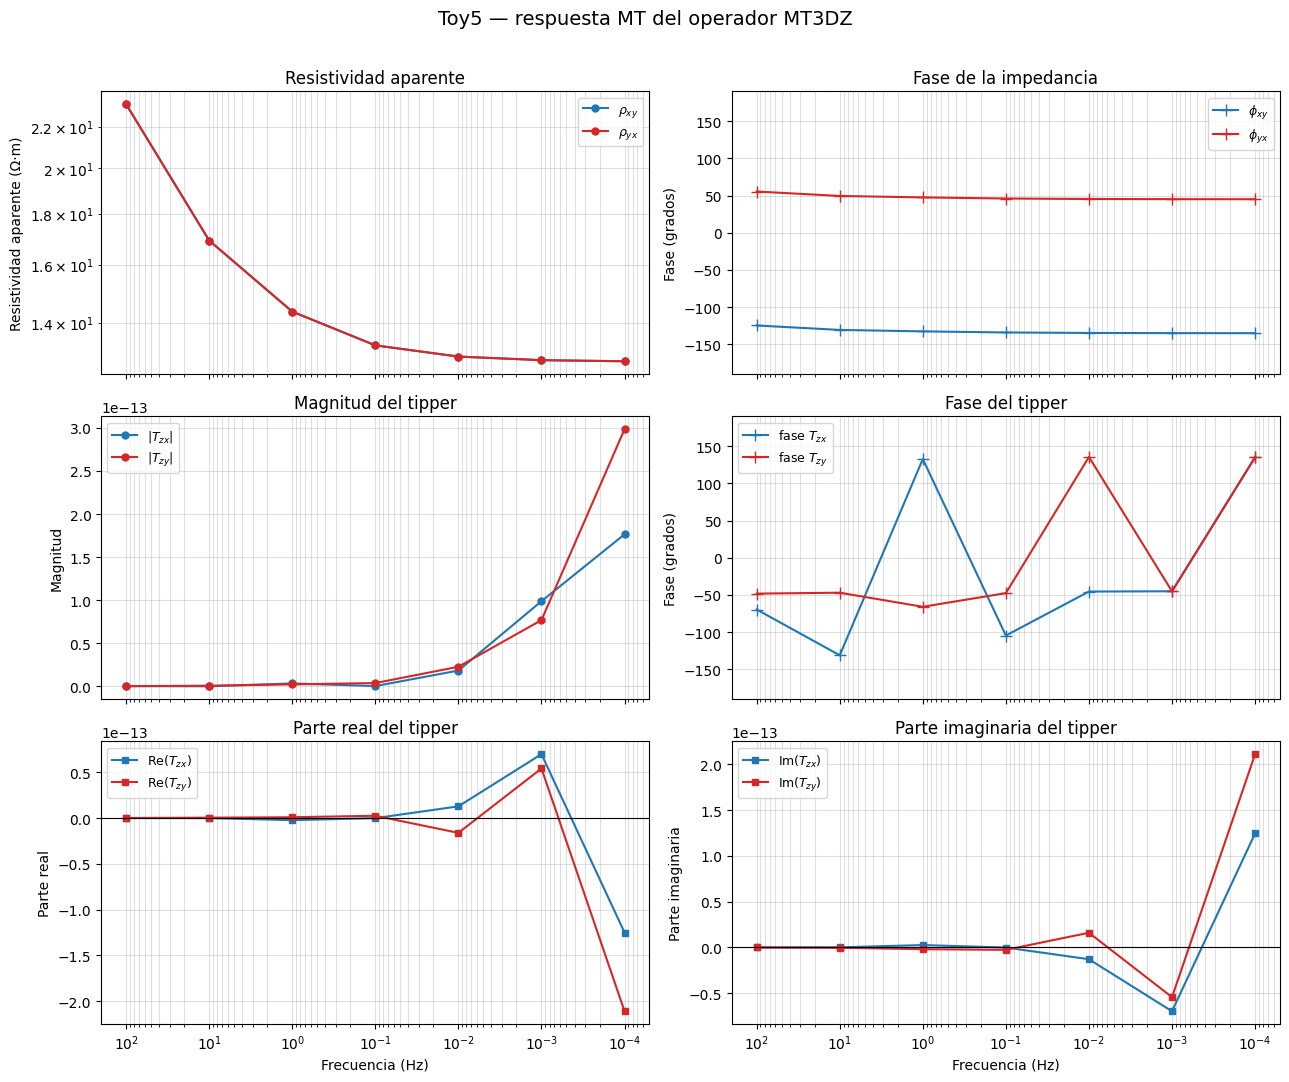

In [5]:
# 4) Figura unica: resistividad aparente, fase y tipper (operador MT3DZ)
irec = 0
frec = frequency_list

c_xy, c_yx = "tab:blue", "tab:red"

fig, axes = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
(ax_rho, ax_phi), (ax_tmag, ax_tphi), (ax_treal, ax_timag) = axes

# --- Resistividad aparente
ax_rho.plot(frec, rho_xy[irec], "-o", color=c_xy, markersize=5, label=r"$\rho_{xy}$")
ax_rho.plot(frec, rho_yx[irec], "-o", color=c_yx, markersize=5, label=r"$\rho_{yx}$")
ax_rho.set_yscale("log")
ax_rho.set_ylabel("Resistividad aparente (Ω·m)")
ax_rho.set_title("Resistividad aparente")

# --- Fase de la impedancia
ax_phi.plot(frec, phi_xy[irec], "-+", color=c_xy, markersize=9, label=r"$\phi_{xy}$")
ax_phi.plot(frec, phi_yx[irec], "-+", color=c_yx, markersize=9, label=r"$\phi_{yx}$")
ax_phi.set_ylim(-190, 190)
ax_phi.set_ylabel("Fase (grados)")
ax_phi.set_title("Fase de la impedancia")

# --- Magnitud del tipper
ax_tmag.plot(frec, mag_tzx[irec], "-o", color=c_xy, markersize=5, label=r"$|T_{zx}|$")
ax_tmag.plot(frec, mag_tzy[irec], "-o", color=c_yx, markersize=5, label=r"$|T_{zy}|$")
ax_tmag.set_ylabel("Magnitud")
ax_tmag.set_title("Magnitud del tipper")

# --- Fase del tipper
ax_tphi.plot(frec, phi_tzx[irec], "-+", color=c_xy, markersize=9, label=r"fase $T_{zx}$")
ax_tphi.plot(frec, phi_tzy[irec], "-+", color=c_yx, markersize=9, label=r"fase $T_{zy}$")
ax_tphi.set_ylim(-190, 190)
ax_tphi.set_ylabel("Fase (grados)")
ax_tphi.set_title("Fase del tipper")

# --- Parte real e imaginaria del tipper
ax_treal.plot(frec, np.real(Tzx[irec]), "-s", color=c_xy, markersize=4, label=r"Re($T_{zx}$)")
ax_treal.plot(frec, np.real(Tzy[irec]), "-s", color=c_yx, markersize=4, label=r"Re($T_{zy}$)")
ax_treal.set_ylabel("Parte real")
ax_treal.set_title("Parte real del tipper")

ax_timag.plot(frec, np.imag(Tzx[irec]), "-s", color=c_xy, markersize=4, label=r"Im($T_{zx}$)")
ax_timag.plot(frec, np.imag(Tzy[irec]), "-s", color=c_yx, markersize=4, label=r"Im($T_{zy}$)")
ax_timag.set_ylabel("Parte imaginaria")
ax_timag.set_title("Parte imaginaria del tipper")

for ax in axes.ravel():
    ax.set_xscale("log")
    ax.grid(True, which="both", alpha=0.4)
    ax.legend(loc="best", fontsize=9)

for ax in (ax_treal, ax_timag):
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Frecuencia (Hz)")

# El eje x es compartido: basta invertirlo una vez
ax_rho.invert_xaxis()

fig.suptitle("Toy5 — respuesta MT del operador MT3DZ", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("MT3DZ_Toy5.png", dpi=300, bbox_inches="tight")
plt.show()

## Notas

- El operador devuelve `NaN` en las frecuencias donde la matriz de campos magnéticos queda mal
  condicionada; esas frecuencias simplemente no se dibujan.
- A las frecuencias más bajas ($10^{-4}$ Hz) el *skin depth* supera el tamaño del dominio de
  `mesh_Toy5_MT.json`, así que la respuesta queda dominada por los bordes de la malla. Es un
  límite de la malla, no del operador.

### Archivos generados

| Archivo | Contenido |
|---|---|
| `impedance_MT3DZ_Toy5.npy` | tensor de impedancias `Z`, forma `(n_rec, n_freq, 2, 2)` |
| `tipper_MT3DZ_Toy5.npy` | tipper `T`, forma `(n_rec, n_freq, 2)` |
| `MT3DZ_Toy5.png` | resistividad aparente, fase y tipper del operador MT3DZ |